# Analyze EMG data

An **electromyogram (EMG)** measures the electrical activity produced by skeletal muscles. In this notebook, we will analyze the **root mean square (RMS)** of a biceps EMG signal recorded during a bicep curl. RMS processing smooths the raw EMG into a continuous envelope that reflects the overall level of muscle activation over time.

## Analysis Choices

When analyzing EMG data, we can decide to measure the peak EMG, the average EMG, or the area under the EMG, often called the "integrated" EMG signal. See Figure 54 in [this guide](https://hermanwallace.com/download/The_ABC_of_EMG_by_Peter_Konrad.pdf) for an explanation of different quantification methods.

![Three ways to quantify an EMG contraction](emg_schematic.png)

If you'd prefer to run this analysis in LabChart, you can do so following [these instructions](https://cdn.adinstruments.com/adi-web/software-tips/Quantitative-EMG-analysis-in-LabChart.pdf). The code below will allow you to analyze it in Python!

## Python Analysis

<div style="background:#fff3cd; border-left:5px solid #ffc107; padding:12px 16px; border-radius:4px;">
<b>Before you begin:</b>
<ol>
<li>Export a <b>LabChart Text File (.txt)</b> of your EMG recording.</li>
<li>Upload the file to Colab (or place it in the same folder as this notebook).</li>
<li>Change the <code>filename</code> variable in the cell below to exactly match your file name.</li>
</ol>
</div>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Change the filename to EXACTLY match your file
filename = 'baseline_1.txt'

# Define column names
columns = ['time', 'recording']

# Load the data (skip the 6-line LabChart header)
data = np.genfromtxt(filename, dtype=float, usecols=(0, 1), skip_header=6,
                     delimiter='\t', names=columns, encoding='unicode_escape')

recording = data['recording']  # RMS voltage in mV

# LabChart text files can contain a second header block mid-recording, which
# injects NaN values and one very large spurious number. Mark anything outside
# a plausible voltage range as NaN, then interpolate across all NaN values.
recording[recording > 10.0] = np.nan
nans = np.isnan(recording)
x = np.arange(len(recording))
recording[nans] = np.interp(x[nans], x[~nans], recording[~nans])

# Build a continuous timestamp array from the sampling interval
interval   = 0.005  # seconds (from the LabChart header: Interval = 0.005 s)
timestamps = np.arange(len(recording)) * interval

print(f'Loaded {len(timestamps)} samples | duration: {timestamps[-1]:.2f} s | interval: {interval} s')

Loaded 15466 samples | duration: 77.33 s | interval: 0.005 s


## Step 1: Plot the entire dataset

Let's start by plotting the full RMS EMG trace. Each upward deflection corresponds to a moment of increased biceps muscle activity — in this case, one bicep curl. The baseline (resting) voltage is the low, flat region between curls.

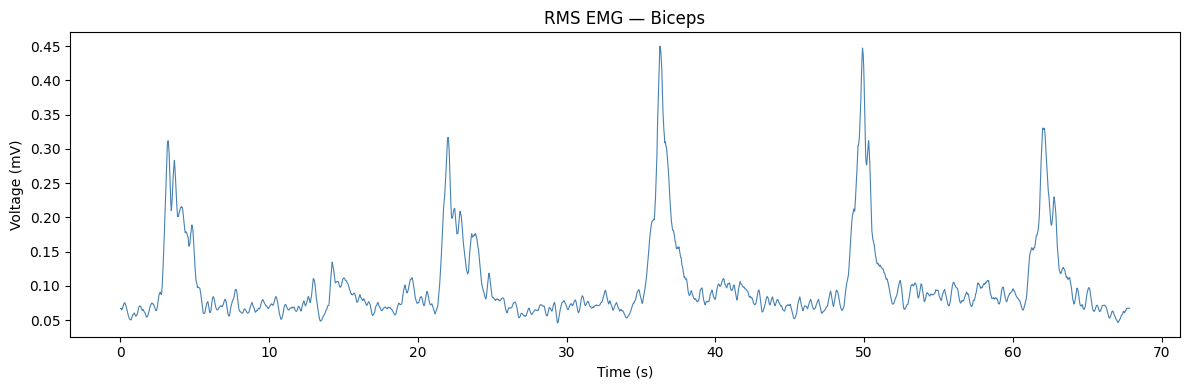

In [40]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(timestamps, recording, linewidth=0.8, color='steelblue')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Voltage (mV)')
ax.set_title('RMS EMG — Biceps')

plt.tight_layout()
plt.show()

## Step 2: Detect bicep curl activations

Next, we'll automatically detect each bicep curl by finding **peaks** in the RMS signal using `scipy.signal.find_peaks`, then clip out the full activation burst — from the local minimum **before** each peak to the local minimum **after** it.

Three key parameters control detection:
- **`height_fraction`** — peaks must exceed this fraction of the recording's maximum voltage (e.g., `0.6` means 60% of max). This adapts automatically to different signal amplitudes.
- **`prominence_threshold`** — peaks must stand out from the surrounding signal by at least this much (mV).
- **`min_peak_distance`** — if two peaks are closer than this many samples, only the taller one is kept.

<div style="background:#fff3cd; border-left:5px solid #ffc107; padding:12px 16px; border-radius:4px;">
<b>Adjust if needed:</b> If too many or too few curls are detected, try increasing or decreasing <code>height_fraction</code> in the cell below.
</div>

In [7]:
# --- Tunable parameters ---
height_fraction      = 0.6    # peaks must exceed this fraction of the recording's max voltage
prominence_threshold = 0.03   # minimum peak prominence in mV
search_window        = 400    # samples to search before/after each peak (~2 s at 200 Hz)
min_peak_distance    = 400    # if two peaks are within this many samples, keep only the tallest

# Adaptive threshold — scales automatically with signal amplitude
height_threshold = height_fraction * recording.max()
print(f'Peak threshold: {height_threshold:.4f} mV ({height_fraction} × max)')

# Find peaks
peaks, _ = signal.find_peaks(recording,
                              height=height_threshold,
                              prominence=prominence_threshold)

# Remove nearby duplicate peaks — greedily keep the tallest within min_peak_distance
sorted_by_height = peaks[np.argsort(recording[peaks])[::-1]]
kept = []
for p in sorted_by_height:
    if all(abs(p - k) >= min_peak_distance for k in kept):
        kept.append(p)
peaks = np.array(sorted(kept))  # restore time order

print(f'Detected {len(peaks)} peak(s) at times: {np.round(timestamps[peaks], 2)} s')

# For each peak, find the full activation burst: local min before → local min after
bursts = []
for peak_idx in peaks:
    pre_start = max(0, peak_idx - search_window)
    start_idx = pre_start + np.argmin(recording[pre_start:peak_idx])

    post_end  = min(len(recording), peak_idx + search_window)
    end_idx   = peak_idx + np.argmin(recording[peak_idx:post_end])

    bursts.append((start_idx, end_idx))

# Standardize burst length — re-extract each burst centered on its peak using
# a half-width equal to the largest half-width seen across all bursts
pre_widths  = [peak - start for peak, (start, _) in zip(peaks, bursts)]
post_widths = [end - peak   for peak, (_, end)   in zip(peaks, bursts)]
half_width  = max(max(pre_widths), max(post_widths))

standardized_bursts = []
for peak_idx in peaks:
    start_idx = max(0, peak_idx - half_width)
    end_idx   = min(len(recording) - 1, peak_idx + half_width)
    standardized_bursts.append((start_idx, end_idx))

print(f'Standardized burst duration: {2 * half_width * interval:.2f} s ({2 * half_width} samples)')

Peak threshold: 0.5212 mV (0.6 × max)
Detected 7 peak(s) at times: [ 3.98 15.36 29.14 45.7  53.3  62.2  70.46] s
Standardized burst duration: 3.61 s (722 samples)


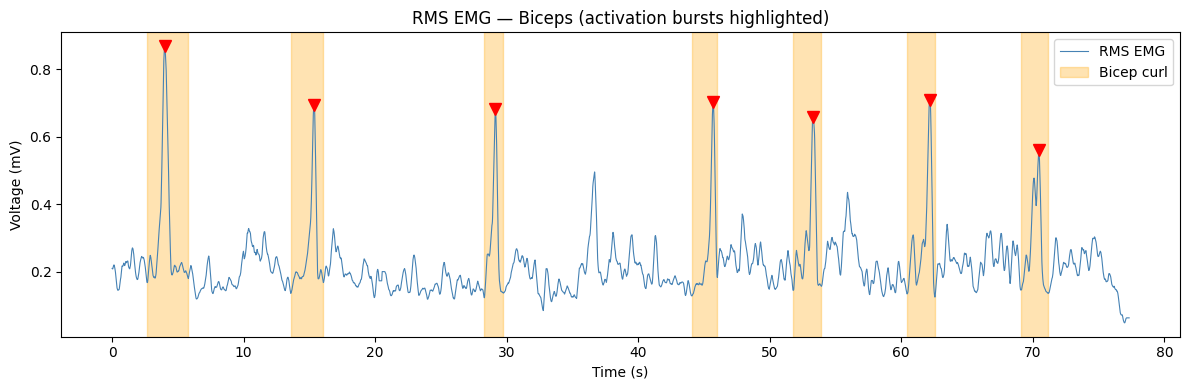

In [8]:
# --- Plot 1: Full trace with activation bursts highlighted ---
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(timestamps, recording, linewidth=0.8, color='steelblue', label='RMS EMG')

for i, (start, end) in enumerate(bursts):
    label = 'Bicep curl' if i == 0 else '_nolegend_'
    ax.axvspan(timestamps[start], timestamps[end], alpha=0.3, color='orange', label=label)
    ax.plot(timestamps[peaks[i]], recording[peaks[i]], 'rv', markersize=8)  # peak marker

ax.set_xlabel('Time (s)')
ax.set_ylabel('Voltage (mV)')
ax.set_title('RMS EMG — Biceps (activation bursts highlighted)')
ax.legend()

plt.tight_layout()
plt.show()

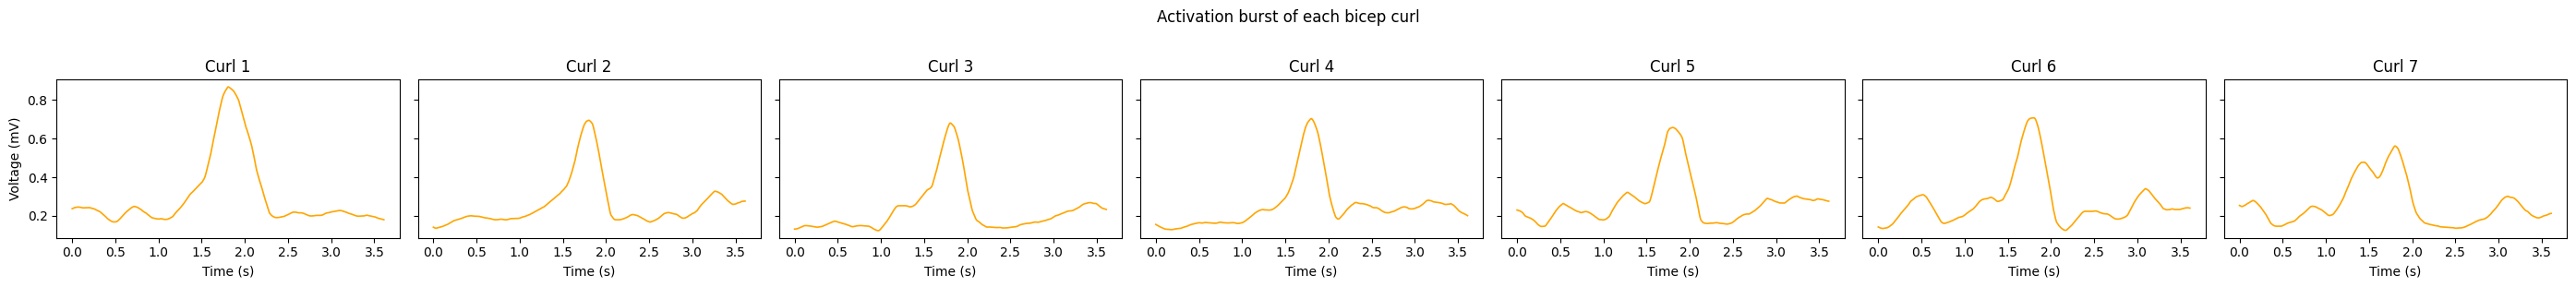

In [9]:
# --- Plot 2: Each activation burst displayed individually (standardized length) ---
n = len(standardized_bursts)

fig, axes = plt.subplots(1, n, figsize=(4 * n, 3), sharey=True)
if n == 1:
    axes = [axes]

for i, (start, end) in enumerate(standardized_bursts):
    t_seg = timestamps[start:end + 1] - timestamps[start]  # zero-align time
    v_seg = recording[start:end + 1]

    axes[i].plot(t_seg, v_seg, color='orange', linewidth=1.2)
    axes[i].set_xlabel('Time (s)')
    axes[i].set_title(f'Curl {i + 1}')

axes[0].set_ylabel('Voltage (mV)')
plt.suptitle('Activation burst of each bicep curl', y=1.02)

plt.tight_layout()
plt.show()

## Step 3: Calculate average EMG during each burst

The **average EMG** (mean voltage during a contraction) measures the typical activation intensity during a burst. Unlike the peak, it's less sensitive to single-sample noise. Unlike the AUC, it's independent of burst duration — making it useful for comparing contractions of different lengths.

Below, we'll calculate the mean RMS voltage within each standardized burst.

In [11]:

# Calculate mean (average) EMG for each standardized burst
means = []
for start, end in standardized_bursts:
    v_seg = recording[start:end + 1]
    means.append(np.mean(v_seg))

# Print results
for i, mean_val in enumerate(means):
    print(f'Curl {i + 1}: Mean EMG = {mean_val:.4f} mV')
print(f'\nMean across all curls: {np.mean(means):.4f} mV')
print(f'Standard deviation:    {np.std(means):.4f} mV')


Curl 1: Mean EMG = 0.3014 mV
Curl 2: Mean EMG = 0.2580 mV
Curl 3: Mean EMG = 0.2291 mV
Curl 4: Mean EMG = 0.2547 mV
Curl 5: Mean EMG = 0.2728 mV
Curl 6: Mean EMG = 0.2724 mV
Curl 7: Mean EMG = 0.2569 mV

Mean across all curls: 0.2636 mV
Standard deviation:    0.0205 mV


## Step 4: Calculate the area under each burst

The **area under the curve (AUC)** of an RMS EMG burst measures total muscle activation — it reflects both how strongly *and* how long the muscle was recruited during each curl. Sometimes this is called the "integrated EMG."

Below, we'll calculate the area using the **trapezoidal rule** (`np.trapezoid`), which approximates the area by summing thin trapezoids under the signal. The result is in units of **mV·s** (millivolt-seconds).

In [12]:
# Calculate AUC for each standardized burst using the trapezoidal rule
areas = []
for start, end in standardized_bursts:
    t_seg = timestamps[start:end + 1] - timestamps[start]
    v_seg = recording[start:end + 1]
    areas.append(np.trapezoid(v_seg, t_seg))

# Print results
for i, area in enumerate(areas):
    print(f'Curl {i + 1}: AUC = {area:.4f} mV·s')
print(f'\nMean AUC: {np.mean(areas):.4f} mV·s')
print(f'Standard Deviation of AUC: {np.std(areas):.4f} mV·s')

Curl 1: AUC = 1.0886 mV·s
Curl 2: AUC = 0.9315 mV·s
Curl 3: AUC = 0.8273 mV·s
Curl 4: AUC = 0.9197 mV·s
Curl 5: AUC = 0.9849 mV·s
Curl 6: AUC = 0.9837 mV·s
Curl 7: AUC = 0.9276 mV·s

Mean AUC: 0.9519 mV·s
Standard Deviation of AUC: 0.0740 mV·s
